## 1. Setup and Initialization
In this section, we import the necessary Python libraries for data manipulation (Pandas, NumPy) and data visualization (Matplotlib, Seaborn). We also set the default Seaborn theme to make our charts look better.

In [1]:
# Import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')


## 2. Data Loading
Here, we load the raw dataset containing the board game information from a CSV file into a Pandas DataFrame so that we can manipulate and analyze it.

In [2]:

# 1. Load the base dataset
# Adjust the path if your notebook is in a different directory than your data
file_path = './raw_data/games.csv'
games_df = pd.read_csv(file_path)


## 3. Initial Data Inspection
We preview the first 5 rows of our dataset to understand its structure and verify it has loaded correctly. It shows various numerical and categorical features of the games.

In [3]:

# Display the first few rows to verify it loaded correctly
display(games_df.head())


,BGGId,Name,Description,YearPublished,GameWeight,AvgRating,BayesAvgRating,StdDev,MinPlayers,MaxPlayers,...,Rank:partygames,Rank:childrensgames,Cat:Thematic,Cat:Strategy,Cat:War,Cat:Family,Cat:CGS,Cat:Abstract,Cat:Party,Cat:Childrens
0,1,Die Macher,die macher game seven sequential political rac...,1986,4.3206,7.61428,7.10363,1.57979,3,5,...,21926,21926,0,1,0,0,0,0,0,0
1,2,Dragonmaster,dragonmaster tricktaking card game base old ga...,1981,1.9630,6.64537,5.78447,1.45440,3,4,...,21926,21926,0,1,0,0,0,0,0,0
2,3,Samurai,samurai set medieval japan player compete gain...,1998,2.4859,7.45601,7.23994,1.18227,2,4,...,21926,21926,0,1,0,0,0,0,0,0
3,4,Tal der Könige,triangular box luxurious large block tal der k...,1992,2.6667,6.60006,5.67954,1.23129,2,4,...,21926,21926,0,0,0,0,0,0,0,0
4,5,Acquire,acquire player strategically invest business t...,1964,2.5031,7.33861,7.14189,1.33583,2,6,...,21926,21926,0,1,0,0,0,0,0,0


## 4. Data Cleaning and Exploration
In this step, we clean the dataset to handle missing values and remove any duplicate entries. We use placeholder strings for missing textual data and the median for numerical variables like recommended age or language ease. Then, we print out some basic summary statistics.

In [4]:

# 2. Data Cleaning & Exploration
print("--- Data Cleaning & Exploration ---")
print(f"Initial shape: {games_df.shape}")

print("\nMissing values per column:")
missing_values = games_df.isnull().sum()
print(missing_values[missing_values > 0])

# Basic Data Cleaning
games_df = games_df.dropna(how='all')
games_df = games_df.drop_duplicates(subset=['BGGId'])

# Handle missing values intelligently
games_df['Description'] = games_df['Description'].fillna('No description available.')
games_df['Family'] = games_df['Family'].fillna('None')
games_df['ImagePath'] = games_df['ImagePath'].fillna('')
games_df['ComAgeRec'] = games_df['ComAgeRec'].fillna(games_df['ComAgeRec'].median())
games_df['LanguageEase'] = games_df['LanguageEase'].fillna(games_df['LanguageEase'].median())

print(f"\nShape after basic cleaning: {games_df.shape}")

print("\nData summary statistics:")
display(games_df.describe(include='all'))

print("\nCSV columns and data types:")
for col in games_df.columns:
    print(f"- {col}: {games_df[col].dtype}")
    # Show values for categorical or small discrete numeric features
    if games_df[col].nunique() < 15:
        print(f"  Unique Values: {games_df[col].unique().tolist()}")


--- Data Cleaning & Exploration ---
Initial shape: (21925, 48)

Missing values per column:
Description         1
ComAgeRec        5530
LanguageEase     5891
Family          15262
ImagePath          17
dtype: int64

Shape after basic cleaning: (21925, 48)

Data summary statistics:


,BGGId,Name,Description,YearPublished,GameWeight,AvgRating,BayesAvgRating,StdDev,MinPlayers,MaxPlayers,...,Rank:partygames,Rank:childrensgames,Cat:Thematic,Cat:Strategy,Cat:War,Cat:Family,Cat:CGS,Cat:Abstract,Cat:Party,Cat:Childrens
count,21925.000000,21925,21925,21925.000000,21925.000000,21925.000000,21925.000000,21925.000000,21925.000000,21925.000000,...,21925.000000,21925.000000,21925.000000,21925.00000,21925.000000,21925.000000,21925.000000,21925.000000,21925.000000,21925.000000
unique,NaN,21521,21904,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Robin Hood,happen black story fiddly morbid mysterious ri...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,6,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,117652.663216,NaN,NaN,1985.494914,1.982131,6.424922,5.685673,1.516374,2.007343,5.707868,...,21295.352201,21062.680274,0.055827,0.10577,0.161003,0.105633,0.013820,0.050855,0.029190,0.040182
std,104628.721777,NaN,NaN,212.486214,0.848983,0.932477,0.365311,0.285578,0.693093,15.014643,...,3637.139987,4219.776597,0.229592,0.30755,0.367542,0.307374,0.116745,0.219707,0.168344,0.196391
min,1.000000,NaN,NaN,-3500.000000,0.000000,1.041330,3.574810,0.196023,0.000000,0.000000,...,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,12346.000000,NaN,NaN,2001.000000,1.333300,5.836960,5.510300,1.320720,2.000000,4.000000,...,21926.000000,21926.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,105305.000000,NaN,NaN,2011.000000,1.968800,6.453950,5.546540,1.476880,2.000000,4.000000,...,21926.000000,21926.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,206169.000000,NaN,NaN,2017.000000,2.525200,7.052450,5.679890,1.665470,2.000000,6.000000,...,21926.000000,21926.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000



CSV columns and data types:
- BGGId: int64
- Name: str
- Description: str
- YearPublished: int64
- GameWeight: float64
- AvgRating: float64
- BayesAvgRating: float64
- StdDev: float64
- MinPlayers: int64
  Unique Values: [3, 2, 1, 4, 8, 0, 6, 5, 10, 7, 9]
- MaxPlayers: int64
- ComAgeRec: float64
- LanguageEase: float64
- BestPlayers: int64
  Unique Values: [5, 0, 3, 4, 6, 2, 7, 8, 1, 13, 12, 15, 14, 9]
- GoodPlayers: str
- NumOwned: int64
- NumWant: int64
- NumWish: int64
- NumWeightVotes: int64
- MfgPlaytime: int64
- ComMinPlaytime: int64
- ComMaxPlaytime: int64
- MfgAgeRec: int64
- NumUserRatings: int64
- NumComments: int64
  Unique Values: [0]
- NumAlternates: int64
- NumExpansions: int64
- NumImplementations: int64
- IsReimplementation: int64
  Unique Values: [0, 1]
- Family: str
- Kickstarted: int64
  Unique Values: [0, 1]
- ImagePath: str
- Rank:boardgame: int64
- Rank:strategygames: int64
- Rank:abstracts: int64
- Rank:familygames: int64
- Rank:thematic: int64
- Rank:cgs: int64

## 5. Feature Engineering
We create new features that will be critical for our recommendation model:
- `TotalEngagement`: Combining ownership, wishes, wants, and user ratings as a proxy for the board game's popularity.
- `MaxPlaytime`: Consolidating missing values in maximum playtimes to have a reliable metric.

In [5]:

# 3. Feature Engineering: Engagement & Playtime
print("\n--- Feature Engineering ---")
games_df['TotalEngagement'] = games_df['NumOwned'] + games_df['NumWant'] + games_df['NumWish'] + games_df['NumUserRatings']

# Consolidate playtime features (using ComMaxPlaytime as an upper bound proxy, fallback to MfgPlaytime)
games_df['MaxPlaytime'] = games_df['ComMaxPlaytime'].replace(0, np.nan).fillna(games_df['MfgPlaytime'])

display(games_df[['Name', 'TotalEngagement', 'MaxPlaytime']].sort_values(by='TotalEngagement', ascending=False).head())



--- Feature Engineering ---


,Name,TotalEngagement,MaxPlaytime
7919,Pandemic,284552,45.0
12,Catan,279141,120.0
673,Carcassonne,275530,45.0
9861,7 Wonders,221519,30.0
14811,Codenames,197544,15.0


## 6. Category Analysis
Since our board game suggester heavily relies on categories (the `Cat:*` features), we extract these category columns and plot a bar chart. This visualizes the overall representation of games across categories such as Strategy, Thematic, or Party.

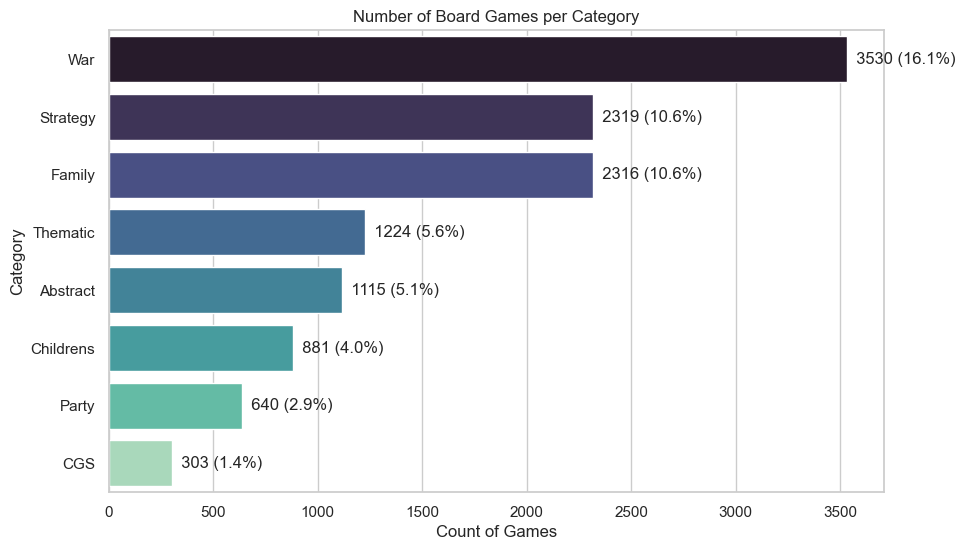

In [6]:
# 4. Analyze Category representations for our Suggester Model
cat_columns = [col for col in games_df.columns if col.startswith('Cat:')]
cat_counts = games_df[cat_columns].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))

# 1. Fix the warning by assigning 'y' to 'hue' and removing the legend
y_labels = [c.replace('Cat:', '') for c in cat_counts.index]
ax = sns.barplot(
    x=cat_counts.values, 
    y=y_labels, 
    hue=y_labels, 
    palette='mako', 
    legend=False
)

plt.title('Number of Board Games per Category')
plt.xlabel('Count of Games')
plt.ylabel('Category')

# 2 & 3. Add data labels with exact counts and percentages
total_games = len(games_df)
for p in ax.patches:
    count = int(p.get_width())
    percentage = (count / total_games) * 100
    ax.annotate(f'  {count} ({percentage:.1f}%)', 
                (count, p.get_y() + p.get_height() / 2.), 
                va='center')

plt.show()

## 7. Correlation Analysis
Finally, we plot a heatmap representing the correlation matrix for the key numerical features. This analysis allows us to understand the linear relationships in the data, e.g., if highly complex games (`GameWeight`) tend to have higher ratings (`AvgRating`).

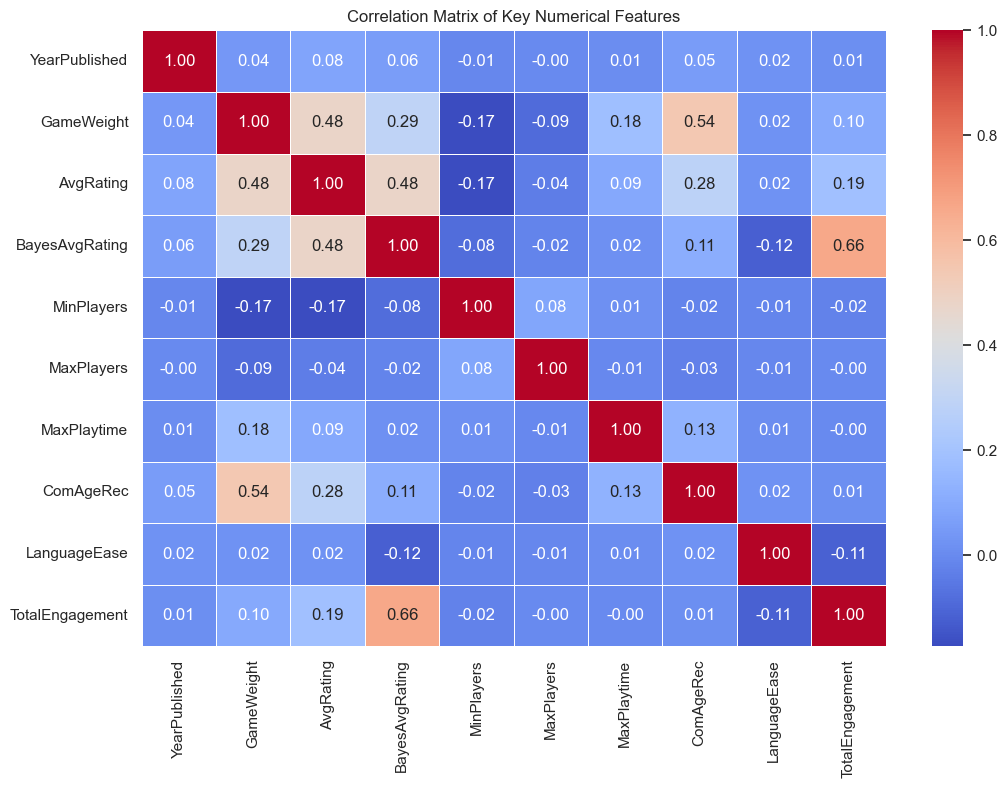

In [7]:

# 5. Evaluate correlations between key numerical features
numeric_cols = ['YearPublished', 'GameWeight', 'AvgRating', 'BayesAvgRating', 
                'MinPlayers', 'MaxPlayers', 'MaxPlaytime', 'ComAgeRec', 
                'LanguageEase', 'TotalEngagement']

plt.figure(figsize=(12, 8))
corr = games_df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Key Numerical Features')
plt.show()

